# TSF vs CPS vs TSCQR vs MSCP — dados contínuos reais

Comparação probabilística de **TSF**, **CPS**, **TSCQR** e **MSCP** em duas séries públicas reais: AirPassengers e temperaturas mínimas diárias de Melbourne. Para o TSF é usada a família Weibull, adequada ao suporte estritamente positivo observado.

In [1]:
from importlib.metadata import version
from pathlib import Path
from time import perf_counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from lightgbm import LGBMRegressor
from mlforecast import MLForecast
from sklearn.ensemble import HistGradientBoostingRegressor

from tinyshift.forecasting import (
    NegativeBinomialFamily,
    TwoStageForecasterWrapper,
    WeibullFamily,
)
from tinyconformal.series import (
    ConformalDistributionTimeSeriesRegressor,
    ConformalQuantileTimeSeriesRegressor,
    ContinuousTimeSeriesConformalPredictiveSystem,
    DiscreteTimeSeriesConformalPredictiveSystem,
)

SEED = 42
H = 14
N_WINDOWS = 12
LEVEL = 0.90
DATA_DIR = Path("data/tsf_cps")
DATA_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

print({"tinyshift": version("tinyshift"), "tinyconformal": version("tinyconformal")})

{'tinyshift': '1.9.3', 'tinyconformal': '0.5.4'}


In [2]:
def make_forecaster(freq, lags):
    model = LGBMRegressor(
        n_estimators=120, learning_rate=0.05, num_leaves=15,
        verbosity=-1, random_state=SEED, n_jobs=1,
    )
    return MLForecast(models={"LGBM": model}, freq=freq, lags=lags)


def make_quantile_forecaster(freq, lags, level=LEVEL):
    alpha = 1-level
    models = {
        "LGBM": LGBMRegressor(
            n_estimators=120, learning_rate=0.05, num_leaves=15,
            verbosity=-1, random_state=SEED, n_jobs=1,
        ),
        "LGBM-lo-90": LGBMRegressor(
            objective="quantile", alpha=alpha/2, n_estimators=120,
            learning_rate=0.05, num_leaves=15, verbosity=-1,
            random_state=SEED, n_jobs=1,
        ),
        "LGBM-hi-90": LGBMRegressor(
            objective="quantile", alpha=1-alpha/2, n_estimators=120,
            learning_rate=0.05, num_leaves=15, verbosity=-1,
            random_state=SEED, n_jobs=1,
        ),
    }
    return MLForecast(models=models, freq=freq, lags=lags)


def fit_tsf(
    train, freq, lags, family, nexcp, weighted_refit,
    h=H, n_windows=N_WINDOWS, step_size=None, decay=0.99,
):
    model = TwoStageForecasterWrapper(make_forecaster(freq, lags), distribution=family)
    tic = perf_counter()
    model.fit(
        train, horizon=h, n_windows=n_windows, step_size=step_size,
        nexcp=nexcp, decay=decay, weighted_refit=weighted_refit,
    )
    fit_seconds = perf_counter() - tic
    tic = perf_counter()
    forecast = model.predict_distribution(h=h)
    predict_seconds = perf_counter() - tic
    return model, forecast, fit_seconds, predict_seconds


def fit_cps(
    train, freq, lags, discrete, h=H, n_windows=N_WINDOWS, step_size=None
):
    cls = (DiscreteTimeSeriesConformalPredictiveSystem if discrete
           else ContinuousTimeSeriesConformalPredictiveSystem)
    model = cls(
        learner=make_forecaster(freq, lags),
        dispersion_learner=HistGradientBoostingRegressor(
            max_iter=80, max_leaf_nodes=8, random_state=SEED
        ),
        horizon=h, n_windows=n_windows, alpha=1-LEVEL,
    )
    tic = perf_counter()
    model.fit(train, step_size=step_size, n_jobs=1)
    fit_seconds = perf_counter() - tic
    tic = perf_counter()
    forecast = model.predict_distribution(h=h)
    predict_seconds = perf_counter() - tic
    return model, forecast, fit_seconds, predict_seconds


def fit_tscqr(train, freq, lags, h=H, n_windows=N_WINDOWS, step_size=None):
    model = ConformalQuantileTimeSeriesRegressor(
        learner=make_quantile_forecaster(freq, lags), horizon=h,
        intervals=("LGBM-lo-90", "LGBM-hi-90"), n_windows=n_windows,
    )
    tic = perf_counter()
    model.fit(train, step_size=step_size, n_jobs=1)
    fit_seconds = perf_counter() - tic
    tic = perf_counter()
    forecast = model.predict_interval(h=h)
    predict_seconds = perf_counter() - tic
    return model, forecast, fit_seconds, predict_seconds


def fit_mscp(train, freq, lags, h=H, n_windows=N_WINDOWS, step_size=None):
    model = ConformalDistributionTimeSeriesRegressor(
        learner=make_forecaster(freq, lags), horizon=h,
        n_windows=n_windows, alpha=1-LEVEL,
    )
    tic = perf_counter()
    model.fit(train, step_size=step_size, n_jobs=1)
    fit_seconds = perf_counter() - tic
    tic = perf_counter()
    forecast = model.predict_interval(h=h)
    predict_seconds = perf_counter() - tic
    return model, forecast, fit_seconds, predict_seconds


def prediction_table(forecast, test, level=LEVEL):
    base = forecast.to_frame().copy()
    intervals = forecast.interval(level)
    quantiles = forecast.ppf([0.5])
    out = base.merge(test[["unique_id", "ds", "y"]], on=["unique_id", "ds"], validate="one_to_one")
    # A branch feature/decay usa Q(0.05), Q(0.5), Q(0.95); versões
    # anteriores usavam sufixos -lo-, -q-50 e -hi-. Em ambos os casos,
    # as colunas projetadas são as únicas que não pertencem ao frame-base.
    interval_cols = [c for c in intervals if c not in base.columns]
    median_cols = [c for c in quantiles if c not in base.columns]
    if len(interval_cols) != 2 or len(median_cols) != 1:
        raise ValueError(
            "Formato inesperado do forecast: "
            f"intervalos={interval_cols}, mediana={median_cols}"
        )
    lo_col, hi_col = interval_cols
    median_col = median_cols[0]
    out["lower"] = intervals[lo_col].to_numpy()
    out["upper"] = intervals[hi_col].to_numpy()
    out["median"] = quantiles[median_col].to_numpy()
    return out


def conformal_prediction_table(forecast, test, method):
    out = forecast.merge(
        test[["unique_id", "ds", "y"]],
        on=["unique_id", "ds"], validate="one_to_one",
    )
    if method == "TSCQR":
        out["lower"] = out["LGBM-lo-90-cqr"]
        out["upper"] = out["LGBM-hi-90-cqr"]
        out["median"] = out["LGBM"]
    elif method == "MSCP":
        out["lower"] = out["LGBM-lo-90"]
        out["upper"] = out["LGBM-hi-90"]
        out["median"] = out["LGBM"]
    else:
        raise ValueError(f"Método conformal desconhecido: {method}")
    return out


def metrics(table, method, dataset, fit_seconds, predict_seconds, level=LEVEL):
    y = table.y.to_numpy(float)
    lo, hi, pred = (table[c].to_numpy(float) for c in ["lower", "upper", "median"])
    alpha = 1-level
    covered = (y >= lo) & (y <= hi)
    winkler = (hi-lo) + (2/alpha)*(lo-y)*(y < lo) + (2/alpha)*(y-hi)*(y > hi)
    return {
        "dataset": dataset, "method": method,
        "RMSE_mediana": np.sqrt(np.mean((y-pred)**2)),
        "MAE_mediana": np.mean(np.abs(y-pred)),
        "cobertura_90": covered.mean(), "largura_media_90": np.mean(hi-lo),
        "Winkler_90": np.mean(winkler), "fit_s": fit_seconds,
        "predict_s": predict_seconds, "n_teste": len(y),
    }


def plot_intervals(tables, title):
    fig, axes = plt.subplots(len(tables), 1, figsize=(13, 3.6*len(tables)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, (name, tab) in zip(axes, tables.items()):
        one = tab[tab.unique_id == tab.unique_id.iloc[0]]
        ax.plot(one.ds, one.y, "o-", color="black", label="observado", ms=3)
        ax.plot(one.ds, one["median"], color="C0", label="mediana")
        ax.fill_between(one.ds, one.lower, one.upper, alpha=.25, label="intervalo 90%")
        ax.set_title(name); ax.legend(ncol=3)
    fig.suptitle(title, y=1.01); plt.tight_layout()


def temporal_split(df, h=H):
    df = df.sort_values(["unique_id", "ds"]).reset_index(drop=True)
    test = df.groupby("unique_id", group_keys=False).tail(h)
    train = df.drop(test.index).reset_index(drop=True)
    return train, test.reset_index(drop=True)

In [3]:
AIR_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
TEMP_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"


def load_air():
    raw = pd.read_csv(AIR_URL)
    return pd.DataFrame({"unique_id": "AirPassengers", "ds": pd.to_datetime(raw.Month),
                         "y": raw.Passengers.astype(float)})


def load_temperature():
    raw = pd.read_csv(TEMP_URL)
    out = pd.DataFrame({"unique_id": "Melbourne", "ds": pd.to_datetime(raw.Date),
                        "y": pd.to_numeric(raw.Temp, errors="coerce")}).dropna()
    # Conversão física exata °C -> K preserva os dados e satisfaz o suporte Weibull.
    out["y"] = out["y"] + 273.15
    # Mantém o trecho diário contíguo mais longo, sem imputar nem sintetizar observações.
    run = out.ds.diff().ne(pd.Timedelta(days=1)).cumsum()
    longest = run.value_counts().idxmax()
    return out[run.eq(longest)].tail(3*365).reset_index(drop=True)


datasets = {"AirPassengers": load_air(), "Melbourne min temperature": load_temperature()}
for name, frame in datasets.items():
    print(name, frame.shape, frame.ds.min(), frame.ds.max(), "mínimo:", frame.y.min())

AirPassengers (144, 3) 1949-01-01 00:00:00 1960-12-01 00:00:00 mínimo: 104.0
Melbourne min temperature (1095, 3) 1982-01-01 00:00:00 1984-12-30 00:00:00 mínimo: 273.15


## Benchmark temporal

A última janela é teste; todas as janelas anteriores são treino/calibração. O mesmo LightGBM, lags, horizonte, 12 janelas e sobreposição são usados pelas duas versões do TSF, CPS, TSCQR e MSCP. O TSF é comparado sem ponderação (`nexcp=False`, `weighted_refit=False`) e com decaimento exponencial tanto na calibração quanto nos ajustes do modelo de média (`nexcp=True`, `weighted_refit=True`, `decay=0.99`). `step_size=3` em AirPassengers e `step_size=7` nas demais séries; como ambos são menores que `H=14`, as janelas se sobrepõem.

In [4]:
results, predictions = [], {}
for dataset_name, df in datasets.items():
    freq = "MS" if dataset_name == "AirPassengers" else ("h" if "Bike" in dataset_name else "D")
    lags = [1, 12] if freq == "MS" else ([1, 24, 168] if freq == "h" else [1, 7, 28])
    step_size = 3 if dataset_name == "AirPassengers" else 7
    train, test = temporal_split(df)

    tsf_configs = {
        "TSF (nexcp=False, weighted_refit=False)": {
            "nexcp": False, "weighted_refit": False,
        },
        "TSF (nexcp=True, weighted_refit=True)": {
            "nexcp": True, "weighted_refit": True,
        },
    }
    for method, config in tsf_configs.items():
        tsf, tsf_fc, tsf_fit, tsf_pred = fit_tsf(
            train, freq, lags, WeibullFamily(), step_size=step_size, **config
        )
        tsf_tab = prediction_table(tsf_fc, test)
        predictions[(dataset_name, method)] = tsf_tab
        results.append(metrics(tsf_tab, method, dataset_name, tsf_fit, tsf_pred))
    cps, cps_fc, cps_fit, cps_pred = fit_cps(
        train, freq, lags, discrete=False, step_size=step_size
    )
    tscqr, tscqr_fc, tscqr_fit, tscqr_pred = fit_tscqr(
        train, freq, lags, step_size=step_size
    )
    mscp, mscp_fc, mscp_fit, mscp_pred = fit_mscp(
        train, freq, lags, step_size=step_size
    )
    cps_tab = prediction_table(cps_fc, test)
    tscqr_tab = conformal_prediction_table(tscqr_fc, test, "TSCQR")
    mscp_tab = conformal_prediction_table(mscp_fc, test, "MSCP")
    predictions[(dataset_name, "CPS")] = cps_tab
    predictions[(dataset_name, "TSCQR")] = tscqr_tab
    predictions[(dataset_name, "MSCP")] = mscp_tab
    results += [
        metrics(cps_tab, "CPS", dataset_name, cps_fit, cps_pred),
        metrics(tscqr_tab, "TSCQR", dataset_name, tscqr_fit, tscqr_pred),
        metrics(mscp_tab, "MSCP", dataset_name, mscp_fit, mscp_pred),
    ]

resultados = pd.DataFrame(results)
display(resultados.round(4))
display(resultados.pivot(index="dataset", columns="method",
                         values=["RMSE_mediana", "cobertura_90", "largura_media_90", "Winkler_90", "fit_s"]).round(4))

/home/heylucasleao/forecasting/.venv/lib/python3.10/site-packages/tinyconformal/series/mscp.py:244: RuntimeWarning: The requested two-sided coverage is not attainable for ConformalDistributionTimeSeriesRegressor with the available calibration sample (n=12); the conformal rank will be clipped to the observed score range.
  return central_conformal_quantile_levels(
/home/heylucasleao/forecasting/.venv/lib/python3.10/site-packages/tinyconformal/series/mscp.py:244: RuntimeWarning: The requested two-sided coverage is not attainable for ConformalDistributionTimeSeriesRegressor with the available calibration sample (n=12); the conformal rank will be clipped to the observed score range.
  return central_conformal_quantile_levels(


,dataset,method,RMSE_mediana,MAE_mediana,cobertura_90,largura_media_90,Winkler_90,fit_s,predict_s,n_teste
0,AirPassengers,"TSF (nexcp=False, weighted_refit=False)",70.8997,49.5696,0.9286,335.0452,351.7433,0.4932,0.0236,14
1,AirPassengers,"TSF (nexcp=True, weighted_refit=True)",62.1774,43.8521,1.0000,300.0127,300.0127,0.5846,0.0230,14
2,AirPassengers,CPS,69.5713,54.1130,0.7857,195.5549,305.0328,1.1965,0.0276,14
3,AirPassengers,TSCQR,72.7590,50.3737,0.8571,392.4095,467.0948,1.0828,0.0677,14
4,AirPassengers,MSCP,72.7590,50.3737,0.7143,173.2623,335.8549,0.4272,0.0238,14
5,Melbourne min temperature,"TSF (nexcp=False, weighted_refit=False)",2.1396,1.6647,1.0000,16.3859,16.3859,0.6143,0.0233,14
6,Melbourne min temperature,"TSF (nexcp=True, weighted_refit=True)",2.8824,2.4076,0.9286,17.1258,17.3035,0.7107,0.0234,14
7,Melbourne min temperature,CPS,2.4154,1.9164,1.0000,13.5136,13.5136,1.2439,0.0270,14
8,Melbourne min temperature,TSCQR,2.6135,1.9392,0.9286,15.4385,15.9787,1.5750,0.0692,14
9,Melbourne min temperature,MSCP,2.6135,1.9392,0.9286,12.0693,12.0732,0.5874,0.0245,14


RMSE_mediana                    \
method                             CPS     MSCP    TSCQR   
dataset                                                    
AirPassengers                  69.5713  72.7590  72.7590   
Melbourne min temperature       2.4154   2.6135   2.6135   

                                                                   \
method                    TSF (nexcp=False, weighted_refit=False)   
dataset                                                             
AirPassengers                                             70.8997   
Melbourne min temperature                                  2.1396   

                                                                cobertura_90  \
method                    TSF (nexcp=True, weighted_refit=True)          CPS   
dataset                                                                        
AirPassengers                                           62.1774       0.7857   
Melbourne min temperature                                2.8824       1.0000   

                                           \
method                       MSCP   TSCQR   
dataset                                     
AirPassengers              0.7143  0.8571   
Melbourne min temperature  0.9286  0.9286   

                                                                   \
method                    TSF (nexcp=False, weighted_refit=False)   
dataset                                                             
AirPassengers                                              0.9286   
Melbourne min temperature                                  1.0000   

                                                                 ...  \
method                    TSF (nexcp=True, weighted_refit=True)  ...   
dataset                                                          ...   
AirPassengers                                            1.0000  ...   
Melbourne min temperature                                0.9286  ...   

                          Winkler_90                      \
method                           CPS      MSCP     TSCQR   
dataset                                                    
AirPassengers               305.0328  335.8549  467.0948   
Melbourne min temperature    13.5136   12.0732   15.9787   

                                                                   \
method                    TSF (nexcp=False, weighted_refit=False)   
dataset                                                             
AirPassengers                                            351.7433   
Melbourne min temperature                                 16.3859   

                                                                  fit_s  \
method                    TSF (nexcp=True, weighted_refit=True)     CPS   
dataset                                                                   
AirPassengers                                          300.0127  1.1965   
Melbourne min temperature                               17.3035  1.2439   

                                           \
method                       MSCP   TSCQR   
dataset                                     
AirPassengers              0.4272  1.0828   
Melbourne min temperature  0.5874  1.5750   

                                                                   \
method                    TSF (nexcp=False, weighted_refit=False)   
dataset                                                             
AirPassengers                                              0.4932   
Melbourne min temperature                                  0.6143   

                                                                 
method                    TSF (nexcp=True, weighted_refit=True)  
dataset                                                          
AirPassengers                                            0.5846  
Melbourne min temperature                                0.7107  

[2 rows x 25 columns]

## Visualização e síntese

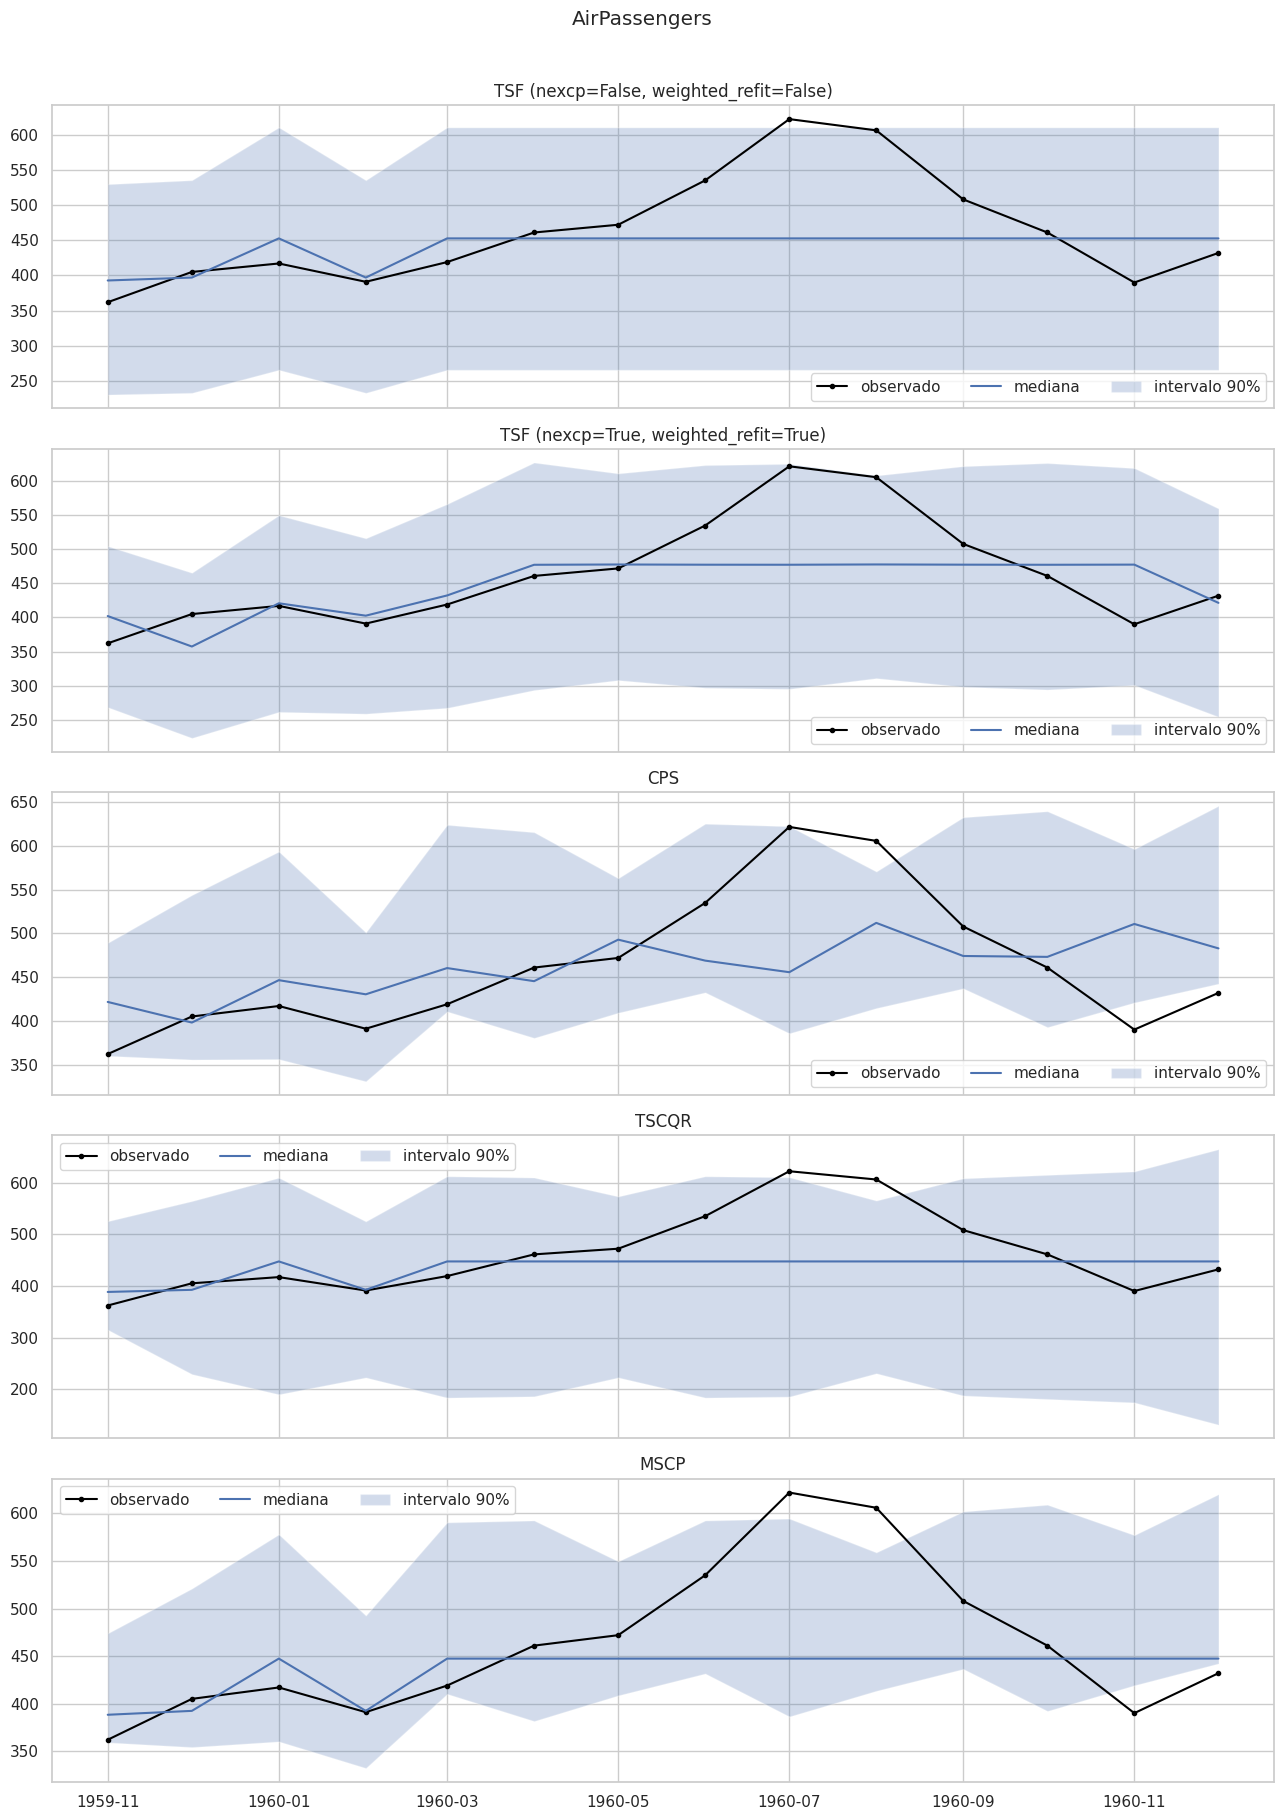

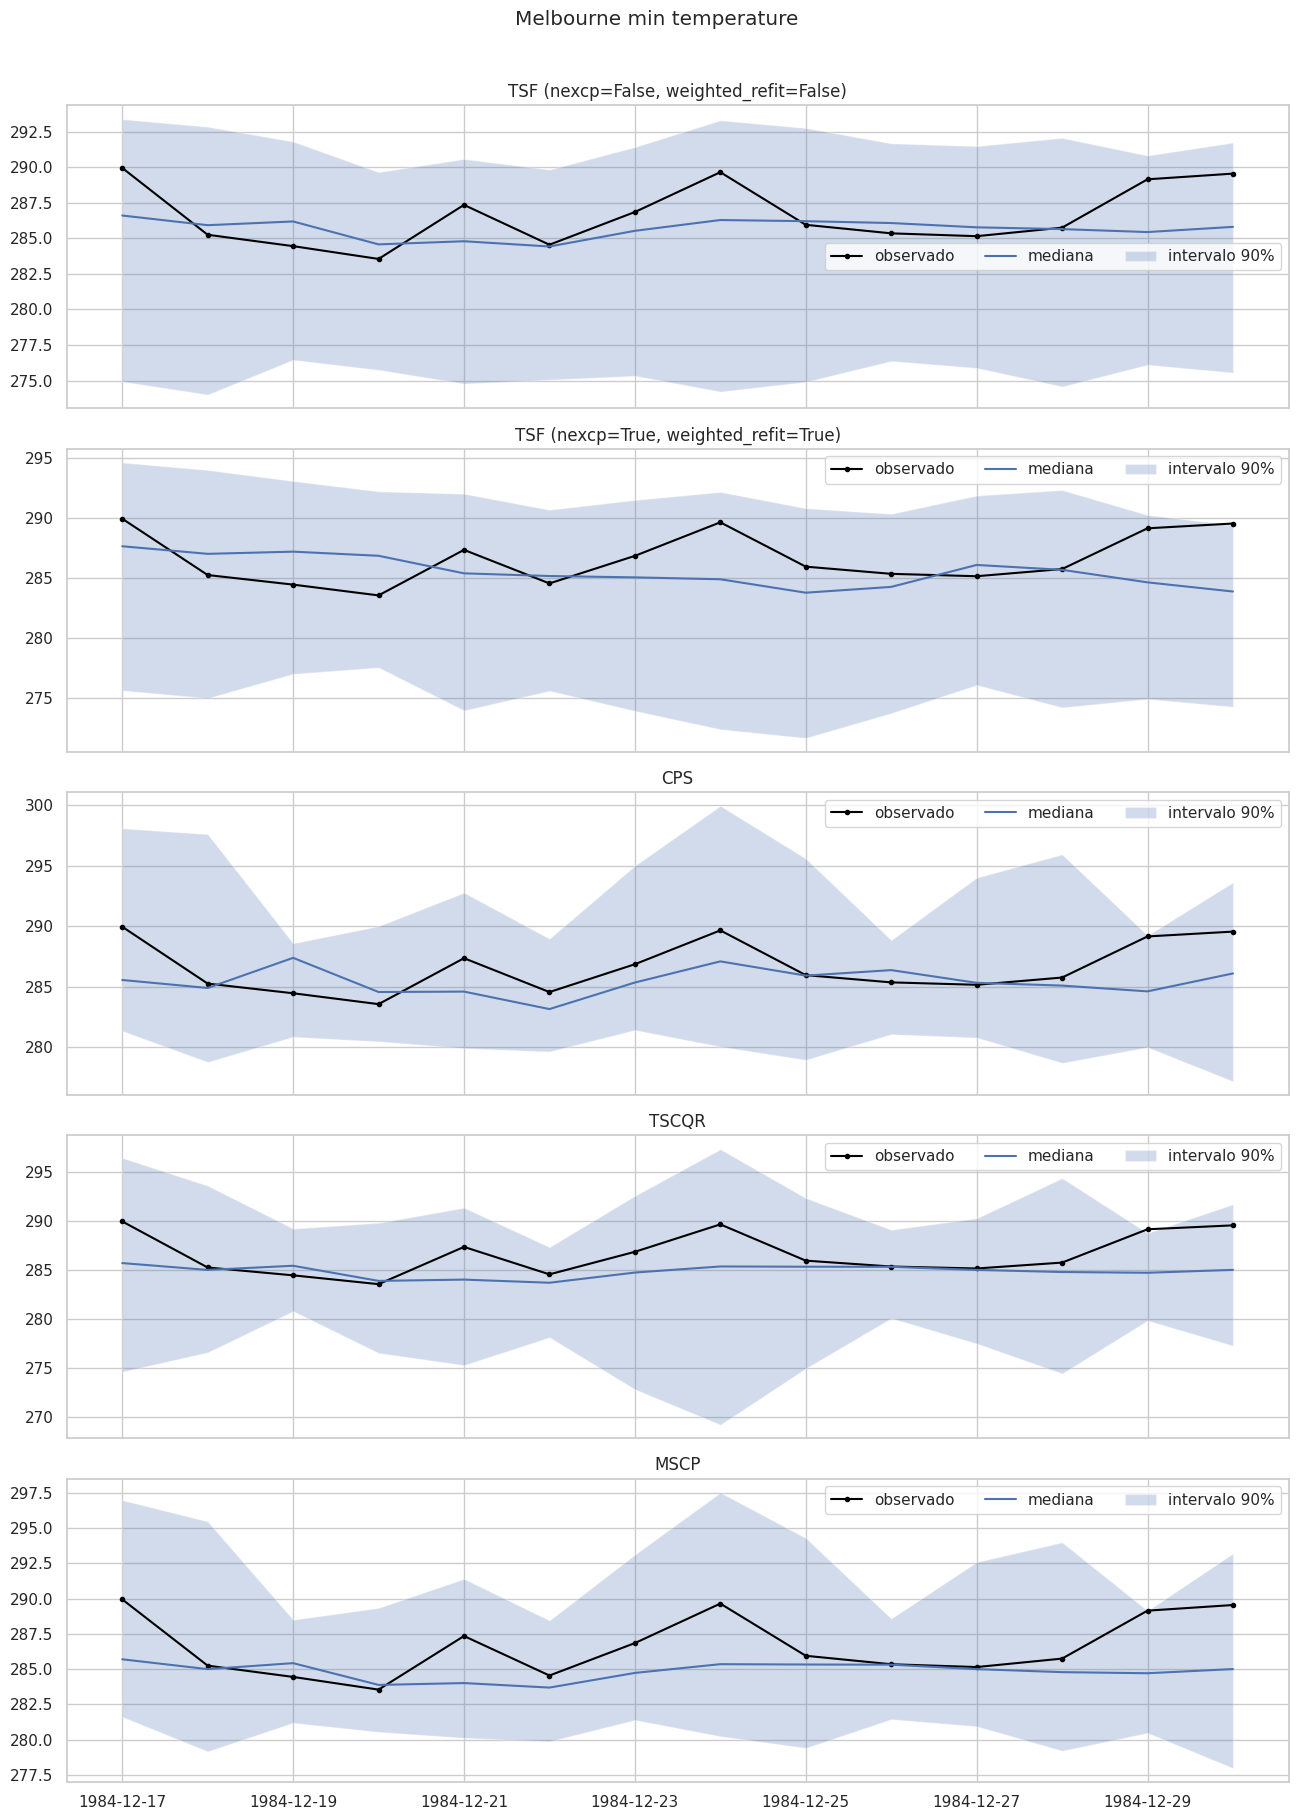

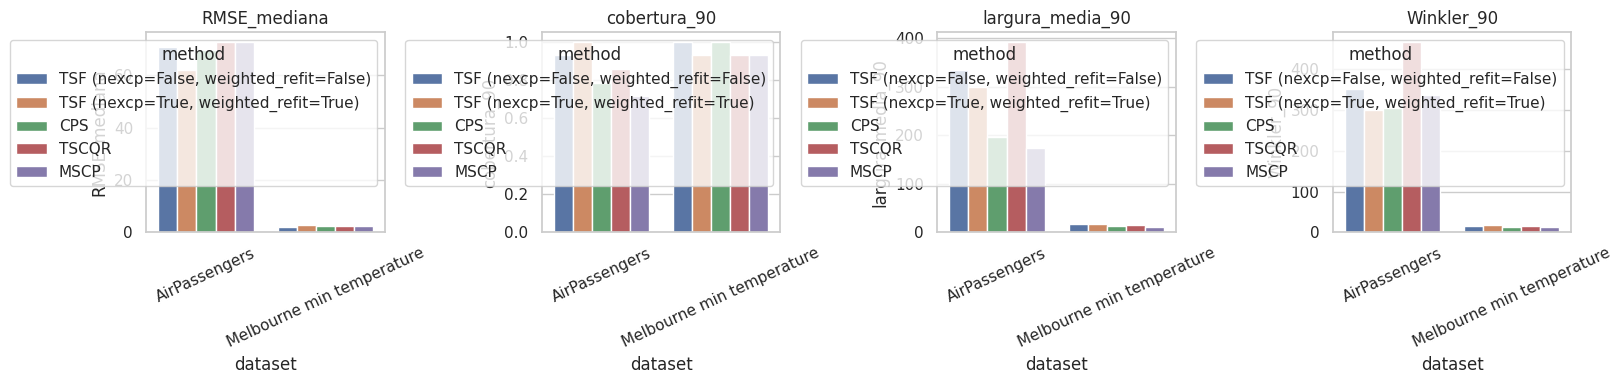

In [5]:
for dataset_name in datasets:
    plot_intervals(
        {method: predictions[(dataset_name, method)] for method in [
            "TSF (nexcp=False, weighted_refit=False)",
            "TSF (nexcp=True, weighted_refit=True)",
            "CPS", "TSCQR", "MSCP",
        ]},
        dataset_name,
    )

metric_cols = ["RMSE_mediana", "cobertura_90", "largura_media_90", "Winkler_90"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, metric in zip(axes, metric_cols):
    sns.barplot(resultados, x="dataset", y=metric, hue="method", ax=ax)
    ax.tick_params(axis="x", rotation=25); ax.set_title(metric)
plt.tight_layout()

In [6]:
def winners(frame):
    rows = []
    for dataset, part in frame.groupby("dataset"):
        target = 0.90
        rows.append({
            "dataset": dataset,
            "menor_RMSE": part.loc[part.RMSE_mediana.idxmin(), "method"],
            "cobertura_mais_próxima_90%": part.loc[(part.cobertura_90-target).abs().idxmin(), "method"],
            "menor_Winkler": part.loc[part.Winkler_90.idxmin(), "method"],
            "fit_mais_rápido": part.loc[part.fit_s.idxmin(), "method"],
        })
    return pd.DataFrame(rows)

display(winners(resultados))
print("Leitura: cobertura isolada não premia intervalos excessivamente largos; por isso Winkler é a métrica principal de intervalo.")

,dataset,menor_RMSE,cobertura_mais_próxima_90%,menor_Winkler,fit_mais_rápido
0,AirPassengers,"TSF (nexcp=True, weighted_refit=True)","TSF (nexcp=False, weighted_refit=False)","TSF (nexcp=True, weighted_refit=True)",MSCP
1,Melbourne min temperature,"TSF (nexcp=False, weighted_refit=False)","TSF (nexcp=True, weighted_refit=True)",MSCP,MSCP


Leitura: cobertura isolada não premia intervalos excessivamente largos; por isso Winkler é a métrica principal de intervalo.


## Reprodutibilidade e ressalvas

- Não há geração de dados sintéticos. As URLs/fontes estão explícitas no notebook.
- Resultados dependem de hardware, versões e da janela temporal escolhida.
- M5 exige aceitar as regras da competição e autenticar o Kaggle uma única vez.
- TSF é paramétrico; CPS, TSCQR e MSCP usam calibração conformal. Nenhum método domina necessariamente em todos os critérios.